In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [35]:
df = pd.read_csv("/Users/suryaprkakash/Desktop/Machine-Learning-and-Deep-Learning/data/Mall_Customers_data.csv")

In [36]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [37]:
X = df[['Age','Annual Income (k$)','Spending Score (1-100)']]

In [38]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

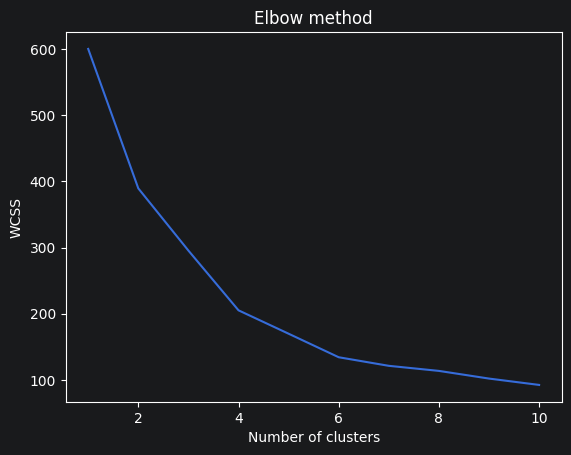

In [39]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss)
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.title("Elbow method")
plt.show()

In [40]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(x_scaled)

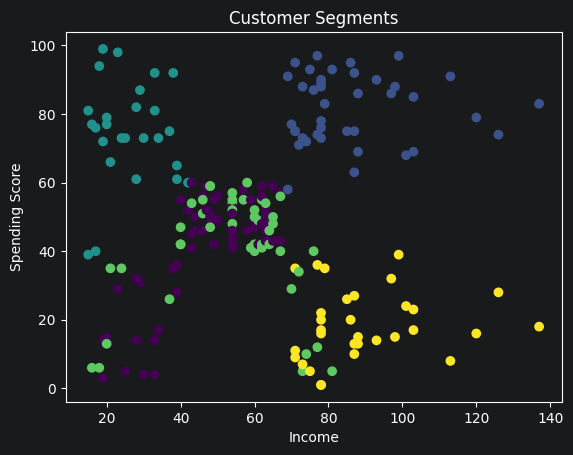

In [41]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster'])
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()

In [42]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
print(cluster_summary)

         CustomerID        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                   
0         68.775862  55.275862           47.620690               41.706897
1        161.025000  32.875000           86.100000               81.525000
2         23.461538  25.769231           26.115385               74.846154
3         86.377778  26.733333           54.311111               40.911111
4        166.870968  44.387097           89.774194               18.483871


In [43]:
df['Cluster_Label'] = df['Cluster'].map({
    0: "Older Moderate Spenders",
    1: "High Value Customers",
    2: "Young High Spenders",
    3: "Average Customers",
    4: "Rich Low Spenders"
})

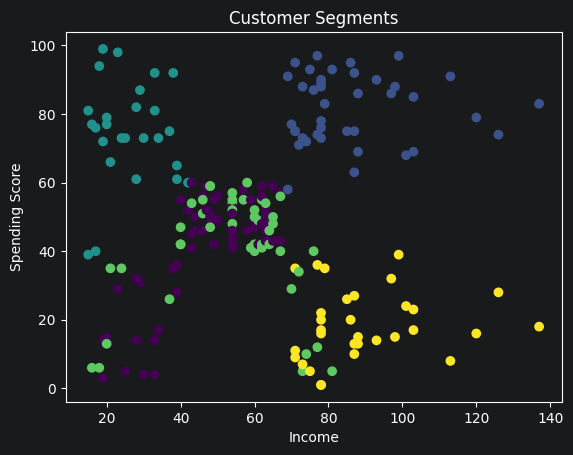

In [44]:
plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],   # numeric
)

plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()